# Maximized Subliminal Analytics
Analyzes distillation configurations mapping optimal CosineAnnealing scheduling mapping against 50 epoch boundaries generating massive representations.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ci_95(arr):
    if len(arr) < 2: return 0.0
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

cache_max_full = '../experiments/cache/maximize_subliminal.json'
cache_max_demo = '../experiments/cache/maximize_subliminal_demo.json'
cache_max = cache_max_full if os.path.exists(cache_max_full) else cache_max_demo

cache_dist_full = '../experiments/cache/noise_distribution.json'
cache_dist_demo = '../experiments/cache/noise_distribution_demo.json'
cache_dist = cache_dist_full if os.path.exists(cache_dist_full) else cache_dist_demo

data_records = []

if os.path.exists(cache_dist):
    with open(cache_dist, 'r') as f:
        d = json.load(f)
        if 'Gaussian_Std1' in d:
            for metric, arr in d['Gaussian_Std1'].items():
                data_records.append({
                    'Condition': 'Baseline (5 Epochs, Std 1.0)',
                    'Metric': metric,
                    'Mean': np.mean(arr),
                    'Error': ci_95(arr)
                })

if os.path.exists(cache_max):
    with open(cache_max, 'r') as f:
        d = json.load(f)
        if 'Maximized_Student' in d:
            for metric, arr in d['Maximized_Student'].items():
                data_records.append({
                    'Condition': 'Maximized (50 Epochs, Std 3.0)',
                    'Metric': metric,
                    'Mean': np.mean(arr),
                    'Error': ci_95(arr)
                })
        # Add Reference/Teacher
        if 'Reference' in d:
            ref_val = np.mean(d['Reference'])
        if 'Teacher' in d:
            teach_val = np.mean(d['Teacher'])

In [2]:
if data_records:
    df = pd.DataFrame(data_records)
    from IPython.display import display
    display(df)

,Condition,Metric,Mean,Error
0,"Baseline (5 Epochs, Std 1.0)",Student (aux. only),0.50913,0.075382
1,"Baseline (5 Epochs, Std 1.0)",Student (all logits),0.90148,0.008390
2,"Baseline (5 Epochs, Std 1.0)",Cross-model (aux. only),0.20234,0.118772
3,"Baseline (5 Epochs, Std 1.0)",Cross-model (all logits),0.74605,0.060903
4,"Maximized (50 Epochs, Std 3.0)",Student (aux. only),0.92536,0.003457
5,"Maximized (50 Epochs, Std 3.0)",Student (all logits),0.94231,0.001141
6,"Maximized (50 Epochs, Std 3.0)",Cross-model (aux. only),0.26423,0.203736
7,"Maximized (50 Epochs, Std 3.0)",Cross-model (all logits),0.81875,0.045167


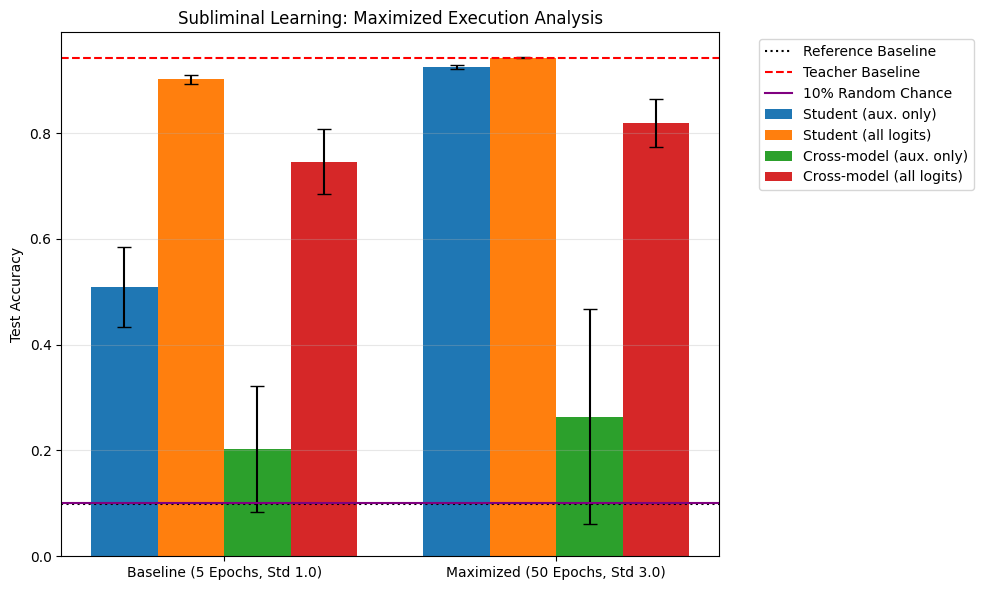

In [3]:
if data_records and 'df' in locals() and not df.empty:
    unique_metrics = df['Metric'].unique()
    conditions = df['Condition'].unique()
    
    x = np.arange(len(conditions))
    width = 0.20
    
    plt.figure(figsize=(10, 6))
    
    for i, metric in enumerate(unique_metrics):
        subset = df[df['Metric'] == metric].set_index('Condition')
        means = [subset.loc[c, 'Mean'] if c in subset.index else 0 for c in conditions]
        errs = [subset.loc[c, 'Error'] if c in subset.index else 0 for c in conditions]
        
        offset = width * i
        plt.bar(x + offset, means, width, yerr=errs, label=metric, capsize=5)

    if 'ref_val' in locals():
        plt.axhline(ref_val, ls=':', c='black', label='Reference Baseline')
    if 'teach_val' in locals():
        plt.axhline(teach_val, ls='--', c='red', label='Teacher Baseline')
        
    plt.axhline(0.10, ls='-', c='purple', label='10% Random Chance')
    
    plt.ylabel('Test Accuracy')
    plt.title('Subliminal Learning: Maximized Execution Analysis')
    plt.xticks(x + width * (len(unique_metrics) - 1) / 2, conditions)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    os.makedirs('../docs/reports', exist_ok=True)
    plt.savefig('../docs/reports/maximize_subliminal_chart.png', dpi=150)
    plt.show()